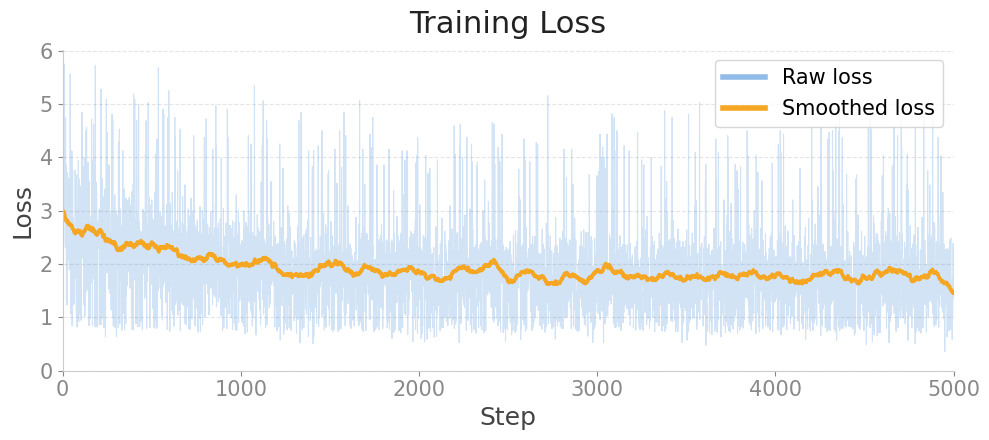

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import json

# --- Shared style (mirrors chapter_3_padding_vizualisations) ---
FIGSIZE      = (10, 4.5)
TITLE_FS     = 22
LABEL_FS     = 18
TICK_FS      = 15
RAW_COLOR    = "#4A90D9"  # darker blue for noisy raw loss
SMOOTH_COLOR = "#F5A623"  # orange for smoothed curve

# --- Load data ---
with open('chapter_3_loss.json', 'r') as f:
    all_loss_values = json.load(f)

loss_values = all_loss_values
df = pd.DataFrame({'Loss': loss_values})
df['Step'] = df.index

window_size = max(10, int(len(df) * 0.02))
df['Smoothed'] = df['Loss'].rolling(window=window_size, min_periods=1, center=True).mean()

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(df['Step'], df['Loss'],     color=RAW_COLOR,    alpha=0.25, linewidth=0.8)
ax.plot(df['Step'], df['Smoothed'], color=SMOOTH_COLOR, linewidth=2.5)

# Style
ax.set_title('Training Loss', fontsize=TITLE_FS, pad=12)
ax.set_xlabel('Step', fontsize=LABEL_FS)
ax.set_ylabel('Loss', fontsize=LABEL_FS)
ax.tick_params(labelsize=TICK_FS, colors='#888888')
ax.set_xlim(0, len(df) - 1)
ax.set_ylim(bottom=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.xaxis.label.set_color('#444444')
ax.yaxis.label.set_color('#444444')
ax.title.set_color('#222222')

ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

# Proxy artists so the raw-loss line shows thick + opaque in the legend
legend_handles = [
    Line2D([0], [0], color=RAW_COLOR,    linewidth=4, alpha=0.6, label='Raw loss'),
    Line2D([0], [0], color=SMOOTH_COLOR, linewidth=4,            label='Smoothed loss'),
]
ax.legend(handles=legend_handles, fontsize=TICK_FS, framealpha=0.8,
          edgecolor='#cccccc', loc='upper right')

plt.tight_layout()
plt.savefig('loss_plot_first_5000_steps.png', dpi=300, bbox_inches='tight')
plt.show()

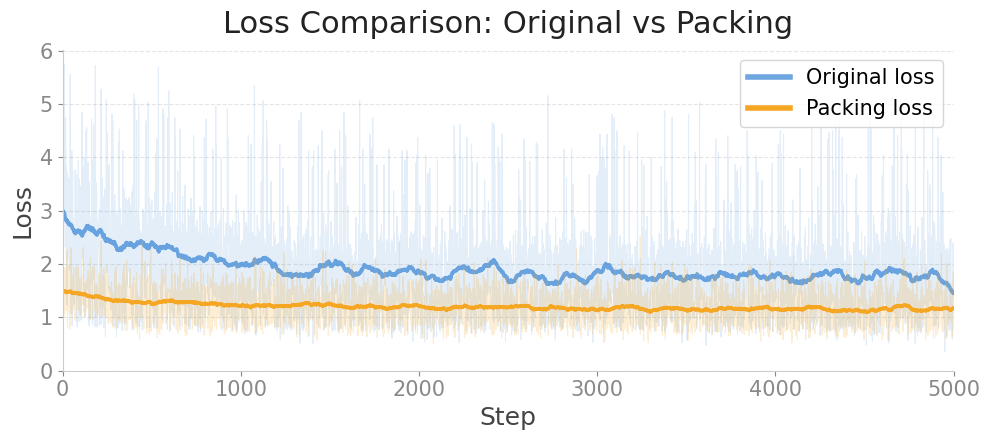

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import json

# --- Shared style ---
FIGSIZE        = (10, 4.5)
TITLE_FS       = 22
LABEL_FS       = 18
TICK_FS        = 15
ORIG_RAW       = "#4A90D9"   # blue — original loss
ORIG_SMOOTH    = "#4A90D9"
BATCH_RAW      = "#F5A623"   # orange — batched/packing loss (highlighted)
BATCH_SMOOTH   = "#F5A623"

# --- Load both datasets ---
with open('chapter_3_loss.json', 'r') as f:
    orig_values = json.load(f)

with open('chapter_3_batched_loss.json', 'r') as f:
    batch_values = json.load(f)

def make_df(values):
    df = pd.DataFrame({'Loss': values})
    df['Step'] = df.index
    window = max(10, int(len(df) * 0.02))
    df['Smoothed'] = df['Loss'].rolling(window=window, min_periods=1, center=True).mean()
    return df

df_orig  = make_df(orig_values)
df_batch = make_df(batch_values)
n_steps  = min(len(df_orig), len(df_batch))

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)

# Original loss — blue, subdued
ax.plot(df_orig['Step'][:n_steps],  df_orig['Loss'][:n_steps],     color=ORIG_RAW,    alpha=0.15, linewidth=0.8)
ax.plot(df_orig['Step'][:n_steps],  df_orig['Smoothed'][:n_steps], color=ORIG_SMOOTH, alpha=0.8,  linewidth=2.5)

# Batched/packing loss — orange, highlighted
ax.plot(df_batch['Step'][:n_steps], df_batch['Loss'][:n_steps],     color=BATCH_RAW,   alpha=0.2,  linewidth=0.8)
ax.plot(df_batch['Step'][:n_steps], df_batch['Smoothed'][:n_steps], color=BATCH_SMOOTH,            linewidth=2.5)

# Style
ax.set_title('Loss Comparison: Original vs Packing', fontsize=TITLE_FS, pad=12)
ax.set_xlabel('Step', fontsize=LABEL_FS)
ax.set_ylabel('Loss', fontsize=LABEL_FS)
ax.tick_params(labelsize=TICK_FS, colors='#888888')
ax.set_xlim(0, n_steps - 1)
ax.set_ylim(bottom=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.xaxis.label.set_color('#444444')
ax.yaxis.label.set_color('#444444')
ax.title.set_color('#222222')

ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

legend_handles = [
    Line2D([0], [0], color=ORIG_SMOOTH,  linewidth=4, alpha=0.8, label='Original loss'),
    Line2D([0], [0], color=BATCH_SMOOTH, linewidth=4,            label='Packing loss'),
]
ax.legend(handles=legend_handles, fontsize=TICK_FS, framealpha=0.8,
          edgecolor='#cccccc', loc='upper right')

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()